# Ejercicio 2 - Criterio de Nyquist

Se propone la siguiente respuesta impulsiva:

$$h(t)=\operatorname{sinc}\left(\frac{t}{T}\right)$$

En este notebook empezamos solamente por el **punto 1**:

1. Graficar la funcion y senalar los instantes de muestreo que permiten cumplir el criterio de Nyquist.

Los puntos 2 y 3 quedan para despues.

## Que dice el criterio de Nyquist

El criterio de Nyquist da una condicion para transmitir simbolos cada `T` segundos sin que un simbolo interfiera con los demas en los instantes de decision del receptor. Esa interferencia entre simbolos se llama **ISI** (`Inter-Symbol Interference`).

Dicho en palabras simples: si envio un simbolo ahora, su pulso puede extenderse en el tiempo, pero debe valer cero justo en los instantes donde el receptor va a decidir los simbolos vecinos. Asi, cuando el receptor muestrea en `t = kT`, solo ve el simbolo que corresponde a ese instante y no una mezcla de simbolos anteriores o posteriores.

En el dominio del tiempo, la condicion ideal se escribe como:

$$p(kT)=\begin{cases}1, & k=0 \\ 0, & k\neq 0\end{cases}$$

Esto significa que el pulso vale `1` en su propio instante de muestreo y `0` en todos los demas multiplos de `T`. Por eso, temporalmente, el criterio sirve para evitar ISI en las muestras tomadas por el receptor.

En el dominio de la frecuencia, el mismo criterio se interpreta como una condicion sobre el espectro del pulso: las replicas periodicas del espectro, separadas por la tasa de simbolos `1/T`, deben sumarse de forma constante. Es decir, no debe haber ni huecos ni excesos que destruyan la condicion de muestreo sin ISI. En forma ideal, para un pulso de Nyquist:

$$\sum_{m=-\infty}^{\infty} P\left(f-\frac{m}{T}\right)=T$$

La idea fisica es que Nyquist conecta dos cosas: en tiempo pide ceros en los instantes de simbolos vecinos; en frecuencia pide una forma espectral compatible con transmitir a una tasa `1/T` sin producir interferencia intersimbolica. Por eso se estudia tanto: permite disenar pulsos que usen el ancho de banda de manera eficiente y que al mismo tiempo sean decodificables muestra a muestra.

---

Uno va a querer siempre periodo de muetreo T para maxima tasa de transmision y que esten mas cerca de 0?

el periodo de 1T me permite cumplir el criterio y lo logro a la maxima tasa posible transferir bytes 

si es en un tiempo menor a t<T no se puede tranferir, ni a mayor ni a menor de T 

## Que es esta funcion y para que se usa

La funcion `sinc` aparece mucho en comunicaciones digitales porque conecta dos ideas centrales: **pulsos en el tiempo** y **limitacion de banda en frecuencia**. En la convencion usada por NumPy y tambien usual en comunicaciones, se define como:

$$\operatorname{sinc}(x)=\frac{\sin(\pi x)}{\pi x}$$

con el valor especial `sinc(0)=1`.

En el libro de Bixio-Rimoldi, esta idea aparece especialmente en el **Capitulo 5**, cuando se estudia la transmision simbolo a simbolo sobre un tren de pulsos. La idea teorica es esta: el transmisor no envia numeros aislados, sino simbolos multiplicando pulsos desplazados en el tiempo. Si los pulsos desplazados no se molestan entre si en los instantes de decision, entonces el receptor puede muestrear sin interferencia intersimbolica, o sea, sin ISI.

La `sinc(t/T)` es importante porque cumple una propiedad muy fuerte:

$$h(0)=1$$

$$h(kT)=0 \quad \text{para todo entero } k \neq 0$$

Eso significa que si se transmite un simbolo usando este pulso, en su propio instante de muestreo aporta valor maximo, pero en los instantes de muestreo de los simbolos vecinos aporta cero. Esa es la base temporal del criterio de Nyquist.

## Contraste con la teoria

En la teoria de Nyquist no alcanza con decir "la senal se ve linda" o "el pulso decae". Lo que importa es que, al muestrear cada `T` segundos, las copias desplazadas del pulso no interfieran entre si.

Si una secuencia de simbolos se transmite como:

$$s(t)=\sum_k a_k h(t-kT)$$

entonces el receptor observa la senal en los instantes `t = nT`. Para que no haya ISI, el pulso debe cumplir:

$$h((n-k)T)=\begin{cases}1, & n=k \\ 0, & n\neq k\end{cases}$$

La `sinc(t/T)` cumple exactamente eso. Por eso la estudiamos: es el ejemplo ideal de pulso de Nyquist. En la practica no siempre se usa una sinc infinita porque dura infinitamente en el tiempo, pero teoricamente es el caso base que permite entender por que existen pulsos como raised cosine y root-raised cosine.

## Punto 1 - Grafica de la funcion e instantes de muestreo

Para graficar tomamos `T = 1`. Esto no cambia la teoria: solamente significa que el eje horizontal esta medido en unidades de `T`. Entonces los instantes de muestreo que cumplen Nyquist son:

$$t = kT, \quad k \in \mathbb{Z}$$

En el grafico vamos a marcar esos puntos. En `t = 0` la funcion vale `1`; en `t = ±T, ±2T, ±3T, ...` la funcion vale `0`.

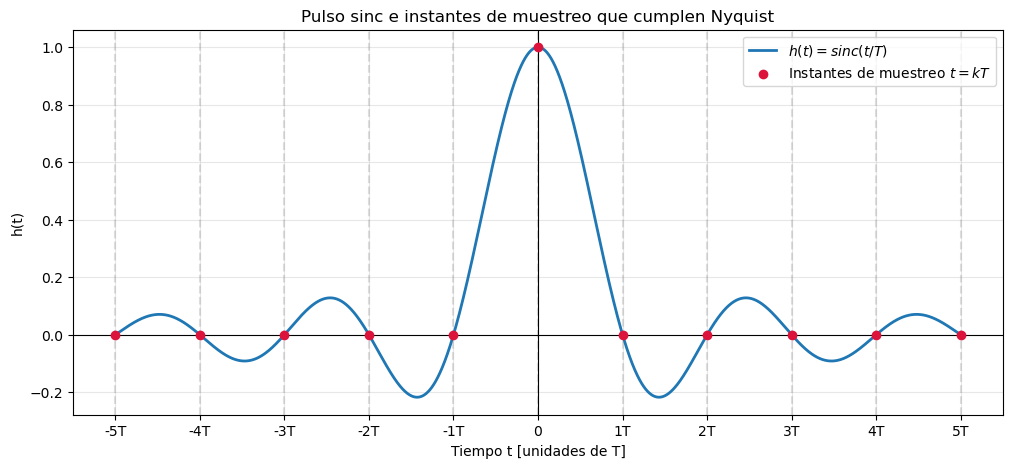

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Elegimos T = 1 para trabajar en tiempo normalizado.
# Si T valiera otra cosa, la forma seria la misma pero estirada o comprimida en el eje t.
T = 1

# Creamos muchos puntos de tiempo entre -5T y 5T para dibujar la curva suave.
# np.linspace(inicio, fin, cantidad) genera un array de puntos igualmente espaciados.
t = np.linspace(-5*T, 5*T, 3000)

# En NumPy, np.sinc(x) implementa sin(pi*x)/(pi*x).
# Por eso h(t) = sinc(t/T) se escribe como np.sinc(t/T).
h = np.sinc(t / T)

# Instantes de muestreo: multiplos enteros de T.
# Estos son los puntos donde el receptor tomaria decisiones.
k = np.arange(-5, 6)
t_muestreo = k * T
h_muestreo = np.sinc(t_muestreo / T)

plt.figure(figsize=(12, 5))
plt.plot(t, h, label=r"$h(t)=sinc(t/T)$", linewidth=2)
plt.scatter(t_muestreo, h_muestreo, color="crimson", zorder=5, label="Instantes de muestreo $t=kT$")

# Dibujamos lineas verticales punteadas en cada instante de muestreo.
for instante in t_muestreo:
    plt.axvline(instante, color="gray", linestyle="--", alpha=0.25)

# Ejes de referencia.
plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(0, color="black", linewidth=0.8)

plt.title("Pulso sinc e instantes de muestreo que cumplen Nyquist")
plt.xlabel("Tiempo t [unidades de T]")
plt.ylabel("h(t)")
plt.xticks(t_muestreo, [f"{i}T" if i != 0 else "0" for i in k])
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Verificacion numerica de los puntos de muestreo

La grafica deberia mostrar que el punto central vale `1` y todos los demas puntos marcados en multiplos de `T` valen `0` o un numero extremadamente cercano a cero por error numerico de la computadora.

In [4]:
# Armamos una tabla simple para ver los valores exactos que se estan marcando.
# np.round(..., 6) redondea para que los errores numericos muy pequenos no molesten.
for ki, ti, hi in zip(k, t_muestreo, h_muestreo):
    print(f"k = {ki:2d} | t = {ti:5.1f}T | h(kT) = {hi: .6f}")

k = -5 | t =  -5.0T | h(kT) =  0.000000
k = -4 | t =  -4.0T | h(kT) = -0.000000
k = -3 | t =  -3.0T | h(kT) =  0.000000
k = -2 | t =  -2.0T | h(kT) = -0.000000
k = -1 | t =  -1.0T | h(kT) =  0.000000
k =  0 | t =   0.0T | h(kT) =  1.000000
k =  1 | t =   1.0T | h(kT) =  0.000000
k =  2 | t =   2.0T | h(kT) = -0.000000
k =  3 | t =   3.0T | h(kT) =  0.000000
k =  4 | t =   4.0T | h(kT) = -0.000000
k =  5 | t =   5.0T | h(kT) =  0.000000


## Conclusion del punto 1

La funcion `sinc(t/T)` cumple el criterio de Nyquist en los instantes `t = kT`. En el instante central `t = 0`, el pulso vale `1`, por lo que el simbolo propio se observa con maxima amplitud. En los demas instantes de muestreo `t = ±T, ±2T, ±3T, ...`, el pulso vale `0`, por lo que no aporta interferencia sobre los simbolos vecinos.

Visto desde la teoria del Bixio, esta propiedad es la que permite construir un tren de pulsos donde el receptor puede tomar una muestra cada `T` segundos y separar los simbolos sin ISI idealmente. La razon por la que se estudia esta funcion es que representa el pulso ideal de Nyquist: perfecto para entender el criterio, aunque dificil de implementar exactamente en la practica porque se extiende infinitamente en el tiempo.

# Punto 2 - Por que elimina ISI en el dominio del tiempo

La ISI aparece cuando, en el instante en que el receptor quiere decidir un simbolo, todavia hay contribuciones de simbolos anteriores o posteriores. En otras palabras, el receptor no ve solamente el simbolo actual, sino una mezcla.

Supongamos que se transmite una secuencia de simbolos `a_k` usando copias desplazadas del pulso `h(t)`:

$$s(t)=\sum_{k=-\infty}^{\infty} a_k h(t-kT)$$

El receptor decide tomando muestras cada `T` segundos. Entonces, en el instante `t=nT`, la senal vale:

$$s(nT)=\sum_{k=-\infty}^{\infty} a_k h(nT-kT)$$

$$s(nT)=\sum_{k=-\infty}^{\infty} a_k h((n-k)T)$$

Ahora entra la propiedad clave de la sinc:

$$h(0)=1$$

$$h(mT)=0 \quad \text{si } m \neq 0$$

Cuando `k = n`, queda `h(0)=1`, entonces sobrevive el simbolo deseado `a_n`. Cuando `k != n`, queda `h((n-k)T)=0`, entonces todos los simbolos vecinos aportan cero justo en ese instante de muestreo.

Por eso:

$$s(nT)=a_n$$

Esto significa que la sinc no elimina que los pulsos se superpongan en todo el tiempo. De hecho, se superponen mucho. Lo importante es que en los instantes exactos de decision, esa superposicion no genera interferencia: solo queda el simbolo que corresponde a ese instante.

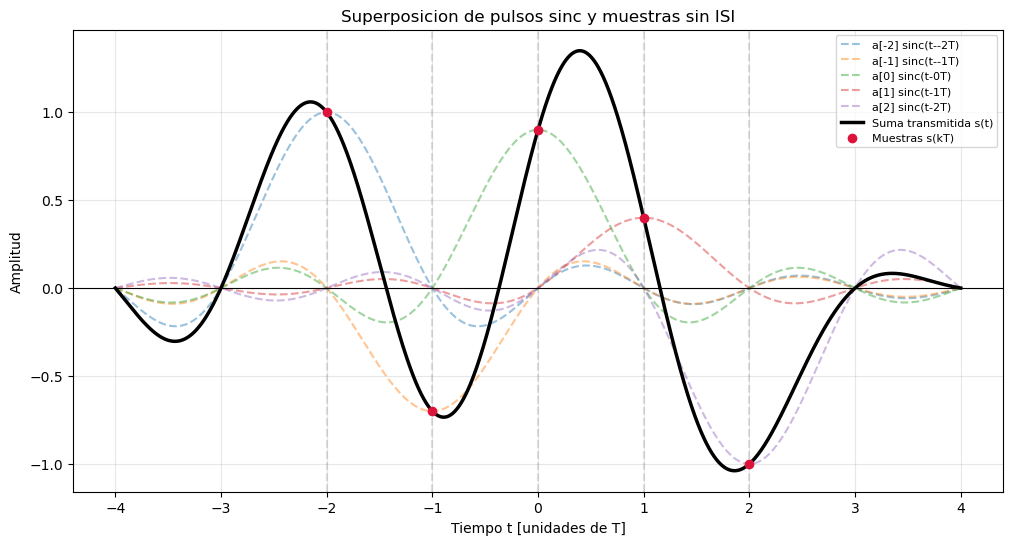

Simbolos originales: [ 1.  -0.7  0.9  0.4 -1. ]
Muestras s(kT):      [ 1.  -0.7  0.9  0.4 -1. ]

Contribuciones de cada pulso en cada instante de muestreo:
Filas: simbolos transmitidos. Columnas: instantes de muestreo.
[[ 1.   0.  -0.   0.  -0. ]
 [-0.  -0.7 -0.   0.  -0. ]
 [-0.   0.   0.9  0.  -0. ]
 [ 0.  -0.   0.   0.4  0. ]
 [ 0.  -0.   0.  -0.  -1. ]]


In [5]:
# Ejemplo visual del punto 2.
# Construimos varios simbolos transmitidos con pulsos sinc desplazados.
# La idea es mirar que pasa justo en los instantes t = kT.

import numpy as np
import matplotlib.pyplot as plt

T = 1
t = np.linspace(-4*T, 4*T, 4000)

# Indices temporales de los simbolos y amplitudes elegidas para el ejemplo.
# No tienen que ser todos iguales: justamente queremos ver que cada muestra recupera su simbolo.
indices_simbolo = np.arange(-2, 3)
simbolos = np.array([1.0, -0.7, 0.9, 0.4, -1.0])

# Cada fila de 'pulsos' es un simbolo multiplicando su sinc desplazada.
pulsos = simbolos[:, None] * np.sinc((t[None, :] - indices_simbolo[:, None]*T) / T)
senal_total = np.sum(pulsos, axis=0)

# Valores exactos de la senal total en los instantes de muestreo.
t_muestreo_2 = indices_simbolo * T
contribuciones = simbolos[:, None] * np.sinc((t_muestreo_2[None, :] - indices_simbolo[:, None]*T) / T)
muestras = np.sum(contribuciones, axis=0)

plt.figure(figsize=(12, 6))

# Pulsos individuales en gris.
for i, pulso in enumerate(pulsos):
    plt.plot(t, pulso, linestyle="--", alpha=0.45, label=f"a[{indices_simbolo[i]}] sinc(t-{indices_simbolo[i]}T)")

# Suma de todos los pulsos.
plt.plot(t, senal_total, color="black", linewidth=2.5, label="Suma transmitida s(t)")
plt.scatter(t_muestreo_2, muestras, color="crimson", zorder=5, label="Muestras s(kT)")

for instante in t_muestreo_2:
    plt.axvline(instante, color="gray", linestyle="--", alpha=0.25)

plt.axhline(0, color="black", linewidth=0.8)
plt.title("Superposicion de pulsos sinc y muestras sin ISI")
plt.xlabel("Tiempo t [unidades de T]")
plt.ylabel("Amplitud")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right", fontsize=8)
plt.show()

print("Simbolos originales:", simbolos)
print("Muestras s(kT):     ", np.round(muestras, 6))
print("\nContribuciones de cada pulso en cada instante de muestreo:")
print("Filas: simbolos transmitidos. Columnas: instantes de muestreo.")
print(np.round(contribuciones, 6))

## Conclusion del punto 2

Desde el dominio del tiempo, esta respuesta impulsiva elimina ISI porque sus ceros estan ubicados exactamente en los multiplos enteros de `T`, excepto en el origen. Cuando el receptor toma una muestra en `t = nT`, el pulso asociado al simbolo `a_n` vale `1`, mientras que todos los pulsos asociados a simbolos vecinos valen `0` en ese mismo instante.

La senal transmitida puede estar formada por muchos pulsos sinc superpuestos, y fuera de los instantes de muestreo esa superposicion existe. Sin embargo, en los instantes de decision `t = nT`, la suma se simplifica: todas las contribuciones vecinas se anulan y queda solamente el simbolo deseado. Por eso se dice que la `sinc(t/T)` es un pulso de Nyquist ideal y permite transmision sin ISI en los instantes de muestreo.

En contraste con una mirada puramente grafica, no alcanza con observar que la sinc decae; lo esencial es que sus cruces por cero coinciden exactamente con los instantes donde el receptor decide los otros simbolos. Esa coincidencia temporal es la razon matematica por la cual se elimina la interferencia intersimbolica.

# PROFESOR AYARDE

la tranformada fourirer de la funcion sinc es discreta en 1/2T  en frecuecia la sumatoria no aporta nada es simplemente el desplazamiento, el criterio dice que la suma de la funcion f    [1/T(sumatoriaG(f-m/T)=1)].   osea la suma de todas da una constante  

# Punto 3 - Espectro cuando se cumple el criterio de Nyquist

Ahora miramos la misma respuesta impulsiva desde el dominio de la frecuencia. Si en el tiempo tenemos:

$$h(t)=\operatorname{sinc}\left(\frac{t}{T}\right)$$

entonces su transformada de Fourier ideal es un rectangulo:

$$H(f)=T\,\operatorname{rect}(fT)$$

Esto significa que el espectro es plano entre:

$$-\frac{1}{2T} \leq f \leq \frac{1}{2T}$$

y vale cero fuera de esa banda.

Aca aparece la idea que anoto el profesor: en frecuencia se miran copias desplazadas del espectro cada `1/T`. El criterio de Nyquist dice que esas copias deben sumar una constante. En una forma normalizada puede escribirse como:

$$\frac{1}{T}\sum_{m=-\infty}^{\infty} H\left(f-\frac{m}{T}\right)=1$$

Para la `sinc(t/T)`, esto se cumple de manera ideal porque los rectangulos desplazados se acomodan uno al lado del otro: no dejan huecos y no se pisan, salvo en los bordes teoricos. Por eso la suma queda constante.

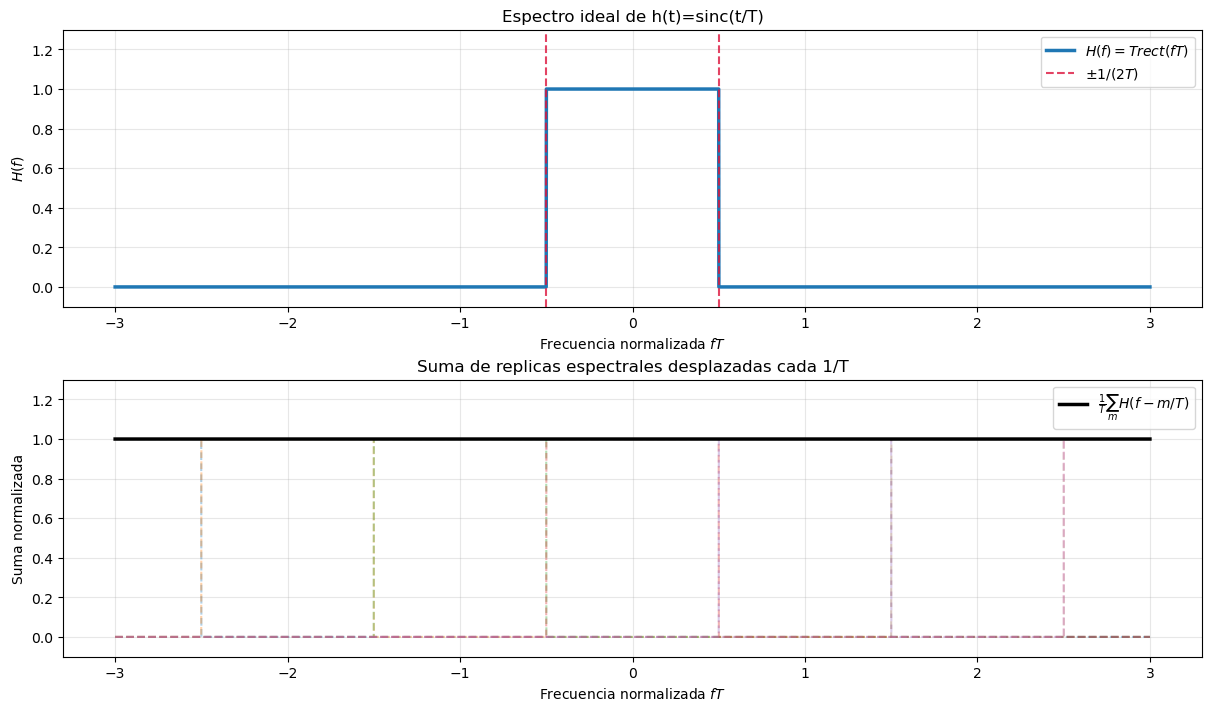

In [6]:
# Grafica en frecuencia del pulso sinc.
# Usamos frecuencia normalizada nu = f*T.
# Con T = 1, nu coincide numericamente con f.

import numpy as np
import matplotlib.pyplot as plt

T = 1
nu = np.linspace(-3, 3, 6000)  # nu = f*T

def rect(x):
    """Rectangulo ideal: vale 1 para |x| < 1/2 y 0 afuera."""
    return np.where(np.abs(x) < 0.5, 1.0, 0.0)

# H(f) = T rect(fT). En frecuencia normalizada: H(nu) = T rect(nu).
H_base = T * rect(nu)

# Replicas desplazadas cada 1/T. En frecuencia normalizada, eso equivale a desplazarlas cada 1.
m_values = np.arange(-3, 4)
replicas = np.array([T * rect(nu - m) for m in m_values])
suma_replicas_normalizada = np.sum(replicas, axis=0) / T

fig, axes = plt.subplots(2, 1, figsize=(12, 7), constrained_layout=True)

axes[0].plot(nu, H_base, linewidth=2.5, label=r"$H(f)=T rect(fT)$")
axes[0].axvline(-0.5, color="crimson", linestyle="--", alpha=0.8, label=r"$\pm 1/(2T)$")
axes[0].axvline(0.5, color="crimson", linestyle="--", alpha=0.8)
axes[0].set_title("Espectro ideal de h(t)=sinc(t/T)")
axes[0].set_xlabel(r"Frecuencia normalizada $fT$")
axes[0].set_ylabel(r"$H(f)$")
axes[0].set_ylim(-0.1, 1.3)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

for m, replica in zip(m_values, replicas):
    axes[1].plot(nu, replica / T, alpha=0.35, linestyle="--")

axes[1].plot(nu, suma_replicas_normalizada, color="black", linewidth=2.5,
             label=r"$\frac{1}{T}\sum_m H(f-m/T)$")
axes[1].set_title("Suma de replicas espectrales desplazadas cada 1/T")
axes[1].set_xlabel(r"Frecuencia normalizada $fT$")
axes[1].set_ylabel("Suma normalizada")
axes[1].set_ylim(-0.1, 1.3)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.show()

## Conclusion del punto 3

En frecuencia, el pulso `sinc(t/T)` se observa como un espectro rectangular ideal limitado a la banda entre `-1/(2T)` y `+1/(2T)`. Esto es importante porque muestra que el pulso sinc ocupa el minimo ancho de banda ideal asociado a una tasa de simbolos `1/T`.

Cuando se cumple el criterio de Nyquist, las replicas del espectro desplazadas cada `1/T` se suman dando una constante. En este caso, como el espectro es rectangular, las replicas quedan una al lado de la otra sin dejar huecos y sin superponerse de forma problematica. Por eso la suma normalizada queda igual a `1`.

La interpretacion es complementaria a la del tiempo: en tiempo vimos que los ceros de la sinc caen justo en los instantes de muestreo vecinos; en frecuencia vemos que el espectro tiene una forma tal que sus replicas periodicas cumplen la condicion de suma constante. Ambas miradas describen la misma propiedad: transmision ideal sin ISI en los instantes de decision.